###|Pulling the Air Quality Data


In [5]:
import requests
import pandas as pd

# Islamabad coordinates
LAT, LON = 33.6844, 73.0479
# Fixed date range = your project is reproducible (same data every run)
START, END = "2022-08-01", "2026-06-30"

aq_url = "https://air-quality-api.open-meteo.com/v1/air-quality"
aq_params = {
    "latitude": LAT, "longitude": LON,
    "hourly": "pm2_5,pm10,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,dust,aerosol_optical_depth",
    "start_date": START, "end_date": END,
    "timezone": "Asia/Karachi",
}
aq = requests.get(aq_url, params=aq_params, timeout=60).json()

if "hourly" not in aq:
    print("SOMETHING WENT WRONG — here's the response:", aq)
else:
    air = pd.DataFrame(aq["hourly"])
    print("Air quality rows:", len(air))
    air.head()

Air quality rows: 34320


###Pulling the Matching Weather Data



In [6]:
wx_url = "https://archive-api.open-meteo.com/v1/archive"
wx_params = {
    "latitude": LAT, "longitude": LON,
    "hourly": "temperature_2m,relative_humidity_2m,dew_point_2m,surface_pressure,wind_speed_10m,wind_direction_10m,precipitation",
    "start_date": START, "end_date": END,
    "timezone": "Asia/Karachi",
}
wx = requests.get(wx_url, params=wx_params, timeout=60).json()

if "hourly" not in wx:
    print("SOMETHING WENT WRONG — here's the response:", wx)
else:
    weather = pd.DataFrame(wx["hourly"])
    print("Weather rows:", len(weather))
    weather.head()

Weather rows: 34320


###Merging , Checking & Saving

In [7]:
import os

df = pd.merge(air, weather, on="time", how="inner")
df["time"] = pd.to_datetime(df["time"])
df = df.sort_values("time").reset_index(drop=True)

print("Merged shape:", df.shape)
print("Date range:", df["time"].min(), "to", df["time"].max())
print("\nColumns:\n", list(df.columns))

os.makedirs("data", exist_ok=True)
df.to_csv("data/islamabad_air_quality.csv", index=False)
print("\nSaved to data/islamabad_air_quality.csv")
df.head()

Merged shape: (34320, 16)
Date range: 2022-08-01 00:00:00 to 2026-06-30 23:00:00

Columns:
 ['time', 'pm2_5', 'pm10', 'carbon_monoxide', 'nitrogen_dioxide', 'sulphur_dioxide', 'ozone', 'dust', 'aerosol_optical_depth', 'temperature_2m', 'relative_humidity_2m', 'dew_point_2m', 'surface_pressure', 'wind_speed_10m', 'wind_direction_10m', 'precipitation']

Saved to data/islamabad_air_quality.csv


,time,pm2_5,pm10,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,dust,aerosol_optical_depth,temperature_2m,relative_humidity_2m,dew_point_2m,surface_pressure,wind_speed_10m,wind_direction_10m,precipitation
0,2022-08-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23.2,91,21.6,942.0,2.5,352,0.0
1,2022-08-01 01:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22.8,93,21.7,941.9,4.5,61,0.0
2,2022-08-01 02:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22.4,94,21.5,942.4,2.8,230,3.0
3,2022-08-01 03:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22.1,95,21.2,942.6,3.2,333,3.0
4,2022-08-01 04:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22.2,94,21.2,942.5,3.3,311,0.5


### Data Health Check

In [8]:
import pandas as pd

# Reload from the saved file so this works even if Colab restarted
df = pd.read_csv("data/islamabad_air_quality.csv", parse_dates=["time"])

# How much is missing in each column?
health = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_%": (df.isna().mean() * 100).round(2)
})
print(health)

# When does the PM2.5 record actually begin and end?
valid = df.loc[df["pm2_5"].notna(), "time"]
print("\nPM2.5 first valid reading:", valid.min())
print("PM2.5 last valid reading: ", valid.max())
print("Total PM2.5 readings present:", valid.count(), "out of", len(df))

                       missing_count  missing_%
time                               0       0.00
pm2_5                             77       0.22
pm10                              77       0.22
carbon_monoxide                   77       0.22
nitrogen_dioxide                  77       0.22
sulphur_dioxide                   77       0.22
ozone                             77       0.22
dust                              77       0.22
aerosol_optical_depth             77       0.22
temperature_2m                     0       0.00
relative_humidity_2m               0       0.00
dew_point_2m                       0       0.00
surface_pressure                   0       0.00
wind_speed_10m                     0       0.00
wind_direction_10m                 0       0.00
precipitation                      0       0.00

PM2.5 first valid reading: 2022-08-04 05:00:00
PM2.5 last valid reading:  2026-06-30 23:00:00
Total PM2.5 readings present: 34243 out of 34320


### Understanding Target Pm2.5

In [9]:
print("PM2.5 summary (µg/m³):")
print(df["pm2_5"].describe().round(1))

PM2.5 summary (µg/m³):
count    34243.0
mean        38.1
std         20.6
min          0.6
25%         23.3
50%         33.8
75%         48.0
max        170.9
Name: pm2_5, dtype: float64


###Plots Describing the story

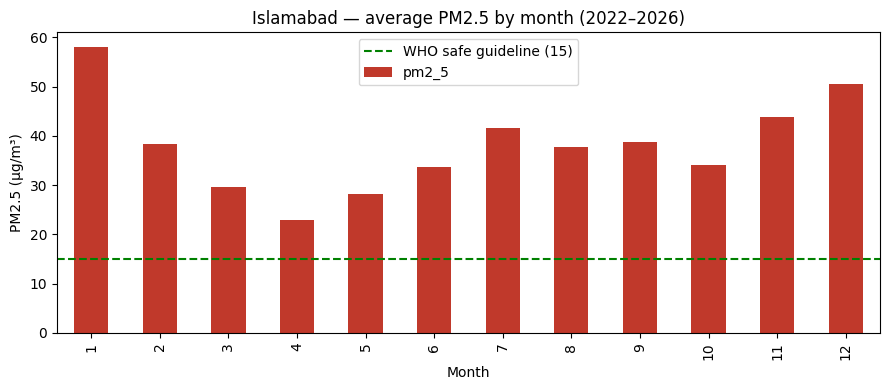

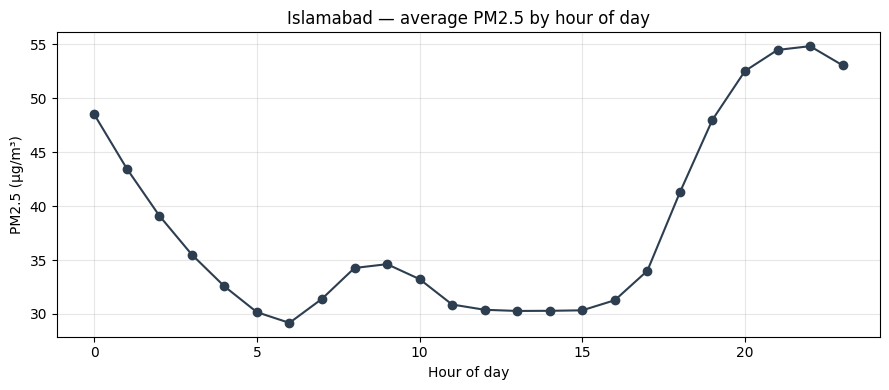

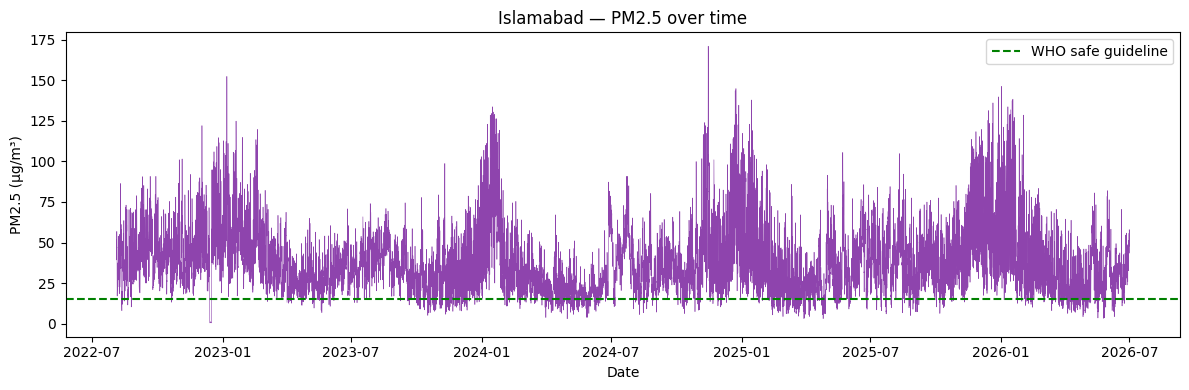

In [10]:
import matplotlib.pyplot as plt

d = df.dropna(subset=["pm2_5"]).copy()
d["month"] = d["time"].dt.month
d["hour"]  = d["time"].dt.hour

# 1) Which months are worst? (the "smog season" question)
plt.figure(figsize=(9, 4))
d.groupby("month")["pm2_5"].mean().plot(kind="bar", color="#c0392b")
plt.axhline(15, color="green", ls="--", label="WHO safe guideline (15)")
plt.title("Islamabad — average PM2.5 by month (2022–2026)")
plt.xlabel("Month"); plt.ylabel("PM2.5 (µg/m³)"); plt.legend()
plt.tight_layout(); plt.show()

# 2) Which hours are worst? (the daily rhythm)
plt.figure(figsize=(9, 4))
d.groupby("hour")["pm2_5"].mean().plot(marker="o", color="#2c3e50")
plt.title("Islamabad — average PM2.5 by hour of day")
plt.xlabel("Hour of day"); plt.ylabel("PM2.5 (µg/m³)")
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

# 3) The full picture over time (watch the winter spikes)
plt.figure(figsize=(12, 4))
plt.plot(d["time"], d["pm2_5"], lw=0.4, color="#8e44ad")
plt.axhline(15, color="green", ls="--", label="WHO safe guideline")
plt.title("Islamabad — PM2.5 over time")
plt.xlabel("Date"); plt.ylabel("PM2.5 (µg/m³)"); plt.legend()
plt.tight_layout(); plt.show()

###Handling Missing Values

In [11]:
import pandas as pd

df = pd.read_csv("data/islamabad_air_quality.csv", parse_dates=["time"])

before = len(df)
df = df.dropna(subset=["pm2_5"]).reset_index(drop=True)  # drop the warm-up gap
after = len(df)
print(f"Dropped {before - after} rows. Remaining: {after}")

print("\nMissing values left in each column:")
print(df.isna().sum())

Dropped 77 rows. Remaining: 34243

Missing values left in each column:
time                     0
pm2_5                    0
pm10                     0
carbon_monoxide          0
nitrogen_dioxide         0
sulphur_dioxide          0
ozone                    0
dust                     0
aerosol_optical_depth    0
temperature_2m           0
relative_humidity_2m     0
dew_point_2m             0
surface_pressure         0
wind_speed_10m           0
wind_direction_10m       0
precipitation            0
dtype: int64


###Validating the timeline is complete

In [12]:
df = df.sort_values("time").reset_index(drop=True)

full_range = pd.date_range(start=df["time"].min(), end=df["time"].max(), freq="h")
missing_hours = full_range.difference(df["time"])
duplicate_times = df["time"].duplicated().sum()

print("Hours expected in this range:", len(full_range))
print("Rows we actually have:      ", len(df))
print("Completely missing hours:   ", len(missing_hours))
print("Duplicate timestamps:       ", duplicate_times)

Hours expected in this range: 34243
Rows we actually have:       34243
Completely missing hours:    0
Duplicate timestamps:        0


###Saving the clean Dataset

In [13]:
df.to_csv("data/islamabad_clean.csv", index=False)
print("Saved clean dataset:", df.shape, "-> data/islamabad_clean.csv")

Saved clean dataset: (34243, 16) -> data/islamabad_clean.csv


###Time Feature

In [14]:
import pandas as pd
import numpy as np

df = pd.read_csv("data/islamabad_clean.csv", parse_dates=["time"])
df = df.sort_values("time").reset_index(drop=True)

# Calendar features
df["hour"]       = df["time"].dt.hour
df["dayofweek"]  = df["time"].dt.dayofweek      # 0 = Monday
df["month"]      = df["time"].dt.month
df["dayofyear"]  = df["time"].dt.dayofyear
df["is_weekend"] = (df["dayofweek"] >= 5).astype(int)

# Cyclical encoding: tells the model that hour 23 sits right next to hour 0,
# and that December (12) is right next to January (1) — otherwise it thinks
# they're as far apart as possible.
df["hour_sin"]  = np.sin(2 * np.pi * df["hour"]  / 24)
df["hour_cos"]  = np.cos(2 * np.pi * df["hour"]  / 24)
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

print("Added time features. Shape now:", df.shape)
df[["time", "hour", "month", "hour_sin", "hour_cos"]].head()

Added time features. Shape now: (34243, 25)


,time,hour,month,hour_sin,hour_cos
0,2022-08-04 05:00:00,5,8,0.965926,2.588190e-01
1,2022-08-04 06:00:00,6,8,1.000000,6.123234e-17
2,2022-08-04 07:00:00,7,8,0.965926,-2.588190e-01
3,2022-08-04 08:00:00,8,8,0.866025,-5.000000e-01
4,2022-08-04 09:00:00,9,8,0.707107,-7.071068e-01


###History & Target

In [15]:
HORIZON = 24   # forecast PM2.5 this many hours ahead (day-ahead warning)

# History clues: PM2.5 at earlier hours (all look backward in time only)
for lag in [1, 2, 3, 6, 12, 24]:
    df[f"pm25_lag_{lag}"] = df["pm2_5"].shift(lag)

# Recent-trend clues: rolling average and volatility over the last hours
df["pm25_roll_mean_3"]  = df["pm2_5"].rolling(3).mean()
df["pm25_roll_mean_24"] = df["pm2_5"].rolling(24).mean()
df["pm25_roll_std_24"]  = df["pm2_5"].rolling(24).std()

# THE TARGET: PM2.5 exactly HORIZON hours into the future
df["target_pm25"] = df["pm2_5"].shift(-HORIZON)

print(f"Built history features + the {HORIZON}h-ahead target.")
print("Shape before trimming edges:", df.shape)

Built history features + the 24h-ahead target.
Shape before trimming edges: (34243, 35)


###Assemble the Modelling table, trim the edges

In [16]:
feature_cols = [
    # current conditions — known at the moment we make the forecast
    "pm2_5", "pm10", "dust",
    "temperature_2m", "relative_humidity_2m", "dew_point_2m",
    "surface_pressure", "wind_speed_10m", "wind_direction_10m", "precipitation",
    # PM2.5 recent history
    "pm25_lag_1", "pm25_lag_2", "pm25_lag_3", "pm25_lag_6", "pm25_lag_12", "pm25_lag_24",
    "pm25_roll_mean_3", "pm25_roll_mean_24", "pm25_roll_std_24",
    # time / calendar
    "hour", "dayofweek", "month", "dayofyear", "is_weekend",
    "hour_sin", "hour_cos", "month_sin", "month_cos",
]

model_df = df[["time"] + feature_cols + ["target_pm25"]].copy()

before = len(model_df)
model_df = model_df.dropna().reset_index(drop=True)   # removes NaN edges from lags (start) + target (end)
after = len(model_df)

print(f"Dropped {before - after} edge rows (early rows have no history; last {HORIZON} have no future to predict).")
print("Final modelling table:", model_df.shape)
print("Number of features:", len(feature_cols))

model_df.to_csv("data/islamabad_features.csv", index=False)
print("Saved -> data/islamabad_features.csv")
model_df.head()

Dropped 48 edge rows (early rows have no history; last 24 have no future to predict).
Final modelling table: (34195, 30)
Number of features: 28
Saved -> data/islamabad_features.csv


,time,pm2_5,pm10,dust,temperature_2m,relative_humidity_2m,dew_point_2m,surface_pressure,wind_speed_10m,wind_direction_10m,...,hour,dayofweek,month,dayofyear,is_weekend,hour_sin,hour_cos,month_sin,month_cos,target_pm25
0,2022-08-05 05:00:00,47.0,67.8,3.0,25.4,92,24.0,945.1,9.3,106,...,5,4,8,217,0,0.965926,2.588190e-01,-0.866025,-0.5,37.5
1,2022-08-05 06:00:00,35.7,51.5,2.0,25.1,91,23.5,945.5,12.2,133,...,6,4,8,217,0,1.000000,6.123234e-17,-0.866025,-0.5,31.8
2,2022-08-05 07:00:00,22.9,33.1,2.0,25.2,87,22.8,945.9,9.7,132,...,7,4,8,217,0,0.965926,-2.588190e-01,-0.866025,-0.5,27.1
3,2022-08-05 08:00:00,18.4,26.5,1.0,26.0,84,23.1,946.1,8.6,123,...,8,4,8,217,0,0.866025,-5.000000e-01,-0.866025,-0.5,25.8
4,2022-08-05 09:00:00,18.7,27.1,1.0,27.3,80,23.5,946.3,8.6,123,...,9,4,8,217,0,0.707107,-7.071068e-01,-0.866025,-0.5,22.9


###Time based split + the baseline

In [17]:
import pandas as pd
import numpy as np

model_df = pd.read_csv("data/islamabad_features.csv", parse_dates=["time"])
model_df = model_df.sort_values("time").reset_index(drop=True)

feature_cols = [c for c in model_df.columns if c not in ["time", "target_pm25"]]
X = model_df[feature_cols]
y = model_df["target_pm25"]

# Split by TIME: last 20% of the timeline is the test set (the future)
split = int(len(model_df) * 0.80)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

print("Train period:", model_df['time'].iloc[0], "->", model_df['time'].iloc[split-1])
print("Test period: ", model_df['time'].iloc[split], "->", model_df['time'].iloc[-1])
print("Train rows:", len(X_train), "| Test rows:", len(X_test))

# BASELINE: "24h from now = right now" (persistence). pm2_5 is the current value.
baseline_pred = X_test["pm2_5"].values
mae_baseline  = np.mean(np.abs(y_test.values - baseline_pred))
rmse_baseline = np.sqrt(np.mean((y_test.values - baseline_pred) ** 2))
print(f"\nBASELINE  — MAE: {mae_baseline:.2f} | RMSE: {rmse_baseline:.2f}  µg/m³")

Train period: 2022-08-05 05:00:00 -> 2025-09-18 00:00:00
Test period:  2025-09-18 01:00:00 -> 2026-06-29 23:00:00
Train rows: 27356 | Test rows: 6839

BASELINE  — MAE: 9.00 | RMSE: 12.73  µg/m³


###Training the model and comparing

In [18]:
from sklearn.ensemble import RandomForestRegressor

# Random Forest: robust, handles non-linear weather/pollution interactions,
# needs almost no tuning to work well. Ideal first model.
model = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=42,
)
model.fit(X_train, y_train)

pred = model.predict(X_test)
mae_model  = np.mean(np.abs(y_test.values - pred))
rmse_model = np.sqrt(np.mean((y_test.values - pred) ** 2))

# R²: fraction of the variation the model explains (1.0 = perfect, 0 = useless)
from sklearn.metrics import r2_score
r2 = r2_score(y_test, pred)

print(f"RANDOM FOREST — MAE: {mae_model:.2f} | RMSE: {rmse_model:.2f} | R²: {r2:.3f}")
print(f"BASELINE      — MAE: {mae_baseline:.2f} | RMSE: {rmse_baseline:.2f}")

improvement = (mae_baseline - mae_model) / mae_baseline * 100
print(f"\nYour model is {improvement:.1f}% better than the naive baseline (by MAE).")

RANDOM FOREST — MAE: 8.61 | RMSE: 11.76 | R²: 0.747
BASELINE      — MAE: 9.00 | RMSE: 12.73

Your model is 4.3% better than the naive baseline (by MAE).


###Givig the model tomorrows weather

In [19]:
import pandas as pd, numpy as np, os

df = pd.read_csv("data/islamabad_clean.csv", parse_dates=["time"]).sort_values("time").reset_index(drop=True)
HORIZON = 24

# time features
df["hour"] = df["time"].dt.hour
df["dayofweek"] = df["time"].dt.dayofweek
df["month"] = df["time"].dt.month
df["dayofyear"] = df["time"].dt.dayofyear
df["is_weekend"] = (df["dayofweek"] >= 5).astype(int)
df["hour_sin"]  = np.sin(2*np.pi*df["hour"]/24);   df["hour_cos"]  = np.cos(2*np.pi*df["hour"]/24)
df["month_sin"] = np.sin(2*np.pi*df["month"]/12);  df["month_cos"] = np.cos(2*np.pi*df["month"]/12)

# history (added a 48h lag too)
for lag in [1,2,3,6,12,24,48]:
    df[f"pm25_lag_{lag}"] = df["pm2_5"].shift(lag)
df["pm25_roll_mean_3"]  = df["pm2_5"].rolling(3).mean()
df["pm25_roll_mean_24"] = df["pm2_5"].rolling(24).mean()
df["pm25_roll_std_24"]  = df["pm2_5"].rolling(24).std()

# NEW: forecast weather = weather at the target hour (t+24).
# In deployment this comes from a weather forecast; using actuals = optimistic proxy.
weather_vars = ["temperature_2m","relative_humidity_2m","dew_point_2m",
                "surface_pressure","wind_speed_10m","wind_direction_10m","precipitation"]
for w in weather_vars:
    df[f"fc_{w}"] = df[w].shift(-HORIZON)

# target
df["target_pm25"] = df["pm2_5"].shift(-HORIZON)

feature_cols = [
    "pm2_5","pm10","dust",
    "temperature_2m","relative_humidity_2m","dew_point_2m",
    "surface_pressure","wind_speed_10m","wind_direction_10m","precipitation",
    "pm25_lag_1","pm25_lag_2","pm25_lag_3","pm25_lag_6","pm25_lag_12","pm25_lag_24","pm25_lag_48",
    "pm25_roll_mean_3","pm25_roll_mean_24","pm25_roll_std_24",
    "hour","dayofweek","month","dayofyear","is_weekend",
    "hour_sin","hour_cos","month_sin","month_cos",
    "fc_temperature_2m","fc_relative_humidity_2m","fc_dew_point_2m",
    "fc_surface_pressure","fc_wind_speed_10m","fc_wind_direction_10m","fc_precipitation",
]

model_df2 = df[["time"]+feature_cols+["target_pm25"]].dropna().reset_index(drop=True)
print("v2 table:", model_df2.shape, "| features:", len(feature_cols))
model_df2.to_csv("data/islamabad_features_v2.csv", index=False)
print("Saved -> data/islamabad_features_v2.csv")

v2 table: (34171, 38) | features: 36
Saved -> data/islamabad_features_v2.csv


 ###Retraining, comparing against v1 and saving the model

In [20]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
import pandas as pd, numpy as np, os, joblib

m = pd.read_csv("data/islamabad_features_v2.csv", parse_dates=["time"]).sort_values("time").reset_index(drop=True)
feat = [c for c in m.columns if c not in ["time","target_pm25"]]
X, y = m[feat], m["target_pm25"]

split = int(len(m)*0.80)
Xtr, Xte, ytr, yte = X.iloc[:split], X.iloc[split:], y.iloc[:split], y.iloc[split:]

# same honest persistence baseline
base = Xte["pm2_5"].values
mae_b = np.mean(np.abs(yte.values-base)); rmse_b = np.sqrt(np.mean((yte.values-base)**2))

rf = RandomForestRegressor(n_estimators=200, min_samples_leaf=2, n_jobs=-1, random_state=42)
rf.fit(Xtr, ytr)
p = rf.predict(Xte)
mae_m = np.mean(np.abs(yte.values-p)); rmse_m = np.sqrt(np.mean((yte.values-p)**2)); r2 = r2_score(yte,p)

print(f"BASELINE            — MAE {mae_b:.2f} | RMSE {rmse_b:.2f}")
print(f"RF v1 (no fc wx)    — MAE 8.61 | RMSE 11.76 | R² 0.747   <- your previous result")
print(f"RF v2 (+ forecast wx)— MAE {mae_m:.2f} | RMSE {rmse_m:.2f} | R² {r2:.3f}")
print(f"\nv2 improvement over baseline: {(mae_b-mae_m)/mae_b*100:.1f}%")

os.makedirs("models", exist_ok=True)
joblib.dump({"model": rf, "features": feat, "split_index": split}, "models/rf_pm25.pkl")
print("Saved model -> models/rf_pm25.pkl")

BASELINE            — MAE 9.00 | RMSE 12.73
RF v1 (no fc wx)    — MAE 8.61 | RMSE 11.76 | R² 0.747   <- your previous result
RF v2 (+ forecast wx)— MAE 8.03 | RMSE 10.99 | R² 0.779

v2 improvement over baseline: 10.9%
Saved model -> models/rf_pm25.pkl


###Feature Importance

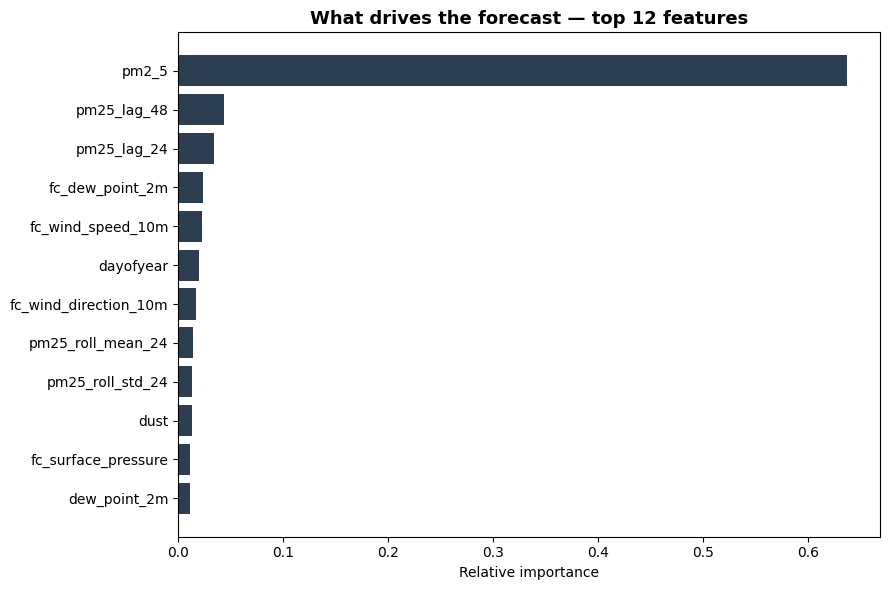

Top 8 features:
pm2_5                    0.636
pm25_lag_48              0.043
pm25_lag_24              0.034
fc_dew_point_2m          0.023
fc_wind_speed_10m        0.022
dayofyear                0.019
fc_wind_direction_10m    0.017
pm25_roll_mean_24        0.014
dtype: float64


In [31]:
import pandas as pd, numpy as np, joblib
import matplotlib.pyplot as plt

bundle = joblib.load("models/rf_pm25.pkl")
rf, feat = bundle["model"], bundle["features"]

imp = pd.Series(rf.feature_importances_, index=feat).sort_values(ascending=False)
top = imp.head(12).iloc[::-1]   # top 12, smallest-to-largest for a clean bar chart

plt.figure(figsize=(9, 6))
plt.barh(top.index, top.values, color="#2c3e50")
plt.title("What drives the forecast — top 12 features", fontsize=13, weight="bold")
plt.xlabel("Relative importance")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print("Top 8 features:")
print(imp.head(8).round(3))

###Predicted vs Actual over the Test period

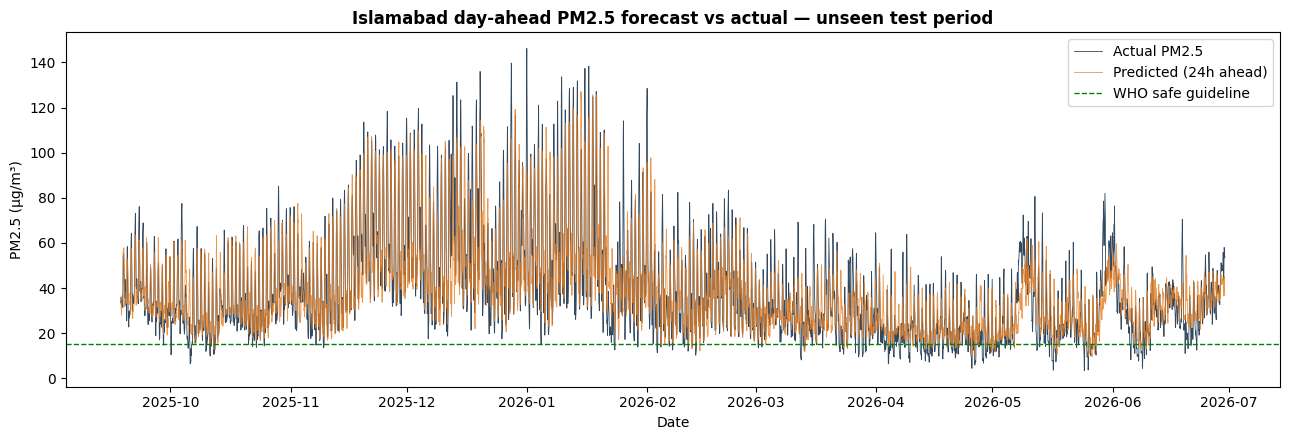

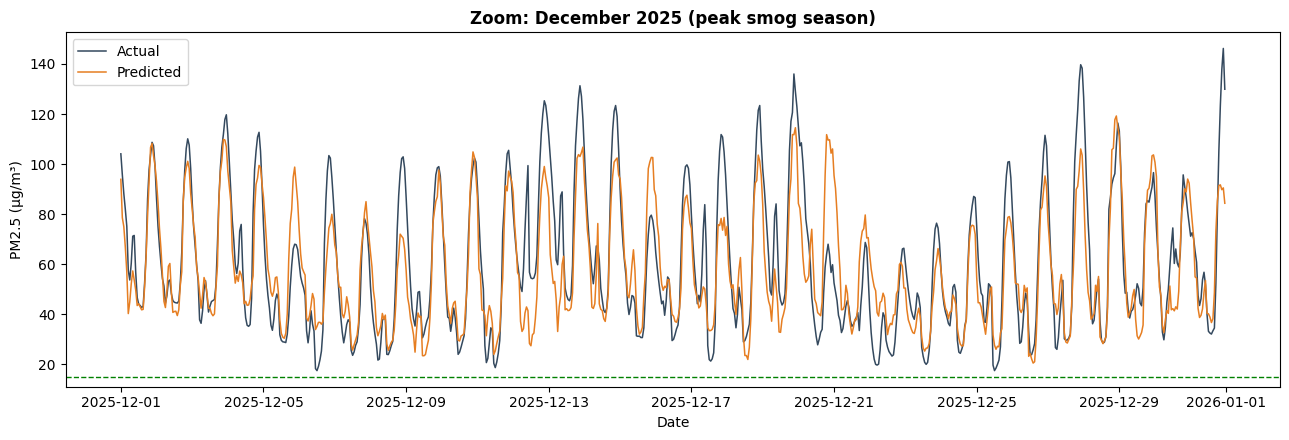

In [32]:
from sklearn.ensemble import RandomForestRegressor
import pandas as pd, numpy as np, joblib
import matplotlib.pyplot as plt

bundle = joblib.load("models/rf_pm25.pkl")
rf, feat, split = bundle["model"], bundle["features"], bundle["split_index"]

m = pd.read_csv("data/islamabad_features_v2.csv", parse_dates=["time"]).sort_values("time").reset_index(drop=True)
Xte = m[feat].iloc[split:]
yte = m["target_pm25"].iloc[split:]
tte = m["time"].iloc[split:]
pred = rf.predict(Xte)

# Full test period: actual vs predicted
plt.figure(figsize=(13, 4.5))
plt.plot(tte, yte.values, lw=0.6, color="#34495e", label="Actual PM2.5")
plt.plot(tte, pred,       lw=0.6, color="#e67e22", alpha=0.8, label="Predicted (24h ahead)")
plt.axhline(15, color="green", ls="--", lw=1, label="WHO safe guideline")
plt.title("Islamabad day-ahead PM2.5 forecast vs actual — unseen test period", weight="bold")
plt.xlabel("Date"); plt.ylabel("PM2.5 (µg/m³)"); plt.legend(loc="upper right")
plt.tight_layout(); plt.savefig("forecast_vs_actual.png", dpi=150, bbox_inches="tight")
plt.show()

# Zoom: one busy winter month (Dec 2025) so the daily tracking is visible
mask = (tte.dt.year == 2025) & (tte.dt.month == 12)
plt.figure(figsize=(13, 4.5))
plt.plot(tte[mask], yte.values[mask], lw=1.1, color="#34495e", label="Actual")
plt.plot(tte[mask], pred[mask],       lw=1.1, color="#e67e22", label="Predicted")
plt.axhline(15, color="green", ls="--", lw=1)
plt.title("Zoom: December 2025 (peak smog season)", weight="bold")
plt.xlabel("Date"); plt.ylabel("PM2.5 (µg/m³)"); plt.legend()
plt.tight_layout(); plt.savefig("forecast_vs_actual_zoom.png", dpi=150, bbox_inches="tight")
plt.show()

###Downloading the three collab data/models file

In [23]:
from google.colab import files
files.download("models/rf_pm25.pkl")
files.download("data/islamabad_clean.csv")
files.download("data/islamabad_features_v2.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

###retrain lean, verify accuracy held, save small

In [30]:
import pandas as pd, numpy as np, os, joblib
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

m = pd.read_csv("data/islamabad_features_v2.csv", parse_dates=["time"]).sort_values("time").reset_index(drop=True)
feat = [c for c in m.columns if c not in ["time", "target_pm25"]]
X, y = m[feat], m["target_pm25"]
split = int(len(m) * 0.80)
Xtr, Xte, ytr, yte = X.iloc[:split], X.iloc[split:], y.iloc[:split], y.iloc[split:]

# Leaner forest: fewer, shallower trees with bigger leaves = much smaller file
rf = RandomForestRegressor(
    n_estimators=120,
    min_samples_leaf=10,   # <-- the main size lever (was 2). Bigger = smaller model
    max_depth=25,          # cap depth so trees can't sprawl
    n_jobs=-1,
    random_state=42,
)
rf.fit(Xtr, ytr)

pred = rf.predict(Xte)
mae  = np.mean(np.abs(yte.values - pred))
rmse = np.sqrt(np.mean((yte.values - pred) ** 2))
r2   = r2_score(yte, pred)
base = Xte["pm2_5"].values
mae_b = np.mean(np.abs(yte.values - base))

print(f"LEAN MODEL   — MAE {mae:.2f} | RMSE {rmse:.2f} | R² {r2:.3f}")
print(f"Your old v2  — MAE 8.03 | RMSE 10.99 | R² 0.779")
print(f"Baseline     — MAE {mae_b:.2f}")
print(f"vs baseline  — {(mae_b - mae)/mae_b*100:.1f}% better")

joblib.dump({"model": rf, "features": feat, "split_index": split},
            "models/rf_pm25.pkl", compress=3)
size_mb = os.path.getsize("models/rf_pm25.pkl") / 1e6
print(f"\nNew model file size: {size_mb:.1f} MB")

LEAN MODEL   — MAE 8.02 | RMSE 10.95 | R² 0.780
Your old v2  — MAE 8.03 | RMSE 10.99 | R² 0.779
Baseline     — MAE 9.00
vs baseline  — 10.9% better

New model file size: 7.8 MB


In [34]:
from google.colab import files; files.download("models/rf_pm25.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>